# Robustness / falsifiers — Hold checklist

**Paper:** §5 (PDF pp. 30–35; Tables 6–9) · **NOTES:** [`NOTES.md`](NOTES.md) · **EXP:** [`EXP_REPORT.md`](EXP_REPORT.md)  
**Scripts:** `scripts/exp_pass2_falsifiers.py` → [`out/pass2/pass2_falsifiers.json`](../../out/pass2/pass2_falsifiers.json)

Paper: GIV for volume, DCM constituents, customer vs inter-bank split. Desk map without bank series: chronological split, block bootstrap, placebo DCM, venue drop, BTC widen. **Never** soft-Promote TOB-cross α.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / "research" / "books" / "cd_me"
OUT = BOOK / "out"
SCRIPTS = BOOK / "scripts"
ROOT = BOOK.parents[2]  # ares-microstructure repo root (research.lib absolute imports)
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(ROOT))
from _nb_common import (
    load_json, expand_pim_hourly, expand_dcm_hourly, day_summary_table, SIGNAL_BOARD,
    load_kraken_inventory, kraken_mode_for_day,
)
from certified_panel import load_certified, primary_days, spot_l2_days
from research.lib import cdme  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_pngs(fig_dir: Path, pattern="*.png"):
    if not fig_dir.is_dir():
        print("no figs dir", fig_dir)
        return
    for p in sorted(fig_dir.glob(pattern)):
        display(Markdown(f"**{p.name}** — `{p.relative_to(BOOK)}`"))
        display(Image(filename=str(p)))

def print_board(rows=None):
    rows = rows or SIGNAL_BOARD
    print(f"{'id':34s} {'gate':6s} note")
    print("-" * 88)
    for i, g, n in rows:
        print(f"{i:34s} {g:6s} {n}")

PASS2 = OUT / "pass2"
KR_INV = load_kraken_inventory(BOOK)
CERT = load_certified()
PRIMARY = primary_days(CERT)
SPOT = spot_l2_days(CERT)
print("BOOK", BOOK)
print("certified primary n=", len(PRIMARY), PRIMARY)
print("spot_l2 subpanel n=", len(SPOT), SPOT)
print("pass2 present", PASS2.is_dir(), "falsifiers", (PASS2 / "pass2_falsifiers.json").is_file())
print("trade_synth QUARANTINED — never primary")


BOOK /home/dev/srv/ares-microstructure/research/books/cd_me
certified primary n= 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
spot_l2 subpanel n= 4 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
pass2 present True falsifiers True
trade_synth QUARANTINED — never primary


In [2]:

el = load_json(OUT / "elasticity_regimes" / "summary.json")
pim_panel = load_json(OUT / "pim_vloop_tcost" / "panel_rows.json") or []
dcm_panel = load_json(OUT / "dcm_proxies" / "panel_rows.json") or []
hourly = expand_dcm_hourly(dcm_panel)
p2 = load_json(PASS2 / "pass2_falsifiers.json") if PASS2.is_dir() else None
pass2_files = sorted(PASS2.rglob("*.json")) if PASS2.is_dir() else []
print("pass2 json files", [str(p.relative_to(OUT)) for p in pass2_files[:30]])
if p2:
    print("pass2 decisions", p2.get("decisions"))
    print("pass2 falsifier ok flags:")
    for k, v in (p2.get("falsifiers") or {}).items():
        print(f"  {k}: ok={v.get('ok') if isinstance(v, dict) else v}")


pass2 json files ['pass2/pass2_falsifiers.json']
pass2 decisions {'risk.pim_cross_venue': 'Hold', 'info.vloop_tcost_commonality': 'Hold', 'risk.dcm_pc1': 'Hold', 'liq.elasticity_regime': 'Hold', 'promote_count': 0, 'note': 'Pass-2 falsifiers run; 0 Promote — monitors only, no TOB-cross α'}
pass2 falsifier ok flags:
  chrono_split: ok=1
  iid_bootstrap_corr: ok=1
  block_bootstrap_by_day: ok=1
  placebo_pim_shuffle: ok=1
  placebo_dcm_regime: ok=0


## Pass-2 falsifiers (artifact) + light notebook preview


{
  "chrono_split": {
    "ok": 1,
    "early_days": [
      "2026-09-14",
      "2026-09-15",
      "2026-09-16",
      "2026-09-17"
    ],
    "late_days": [
      "2026-09-18",
      "2026-09-25",
      "2026-09-26",
      "2026-09-27"
    ],
    "early": {
      "corr": -0.31353529910393085,
      "n": 37,
      "ok": 1
    },
    "late": {
      "corr": -0.5435873195132339,
      "n": 51,
      "ok": 1
    },
    "sign_stable": 1,
    "falsifier": "sign_flip_across_chrono_halves \u2192 weaken Hold"
  },
  "block_bootstrap_by_day": {
    "ok": 1,
    "n_days": 8,
    "corr": -0.4612833556222188,
    "ci_lo": -0.5476746389825109,
    "ci_hi": -0.37363946692209826,
    "n_boot": 400,
    "label": "block_bootstrap_resample_days"
  },
  "placebo_pim_shuffle": {
    "ok": 1,
    "real_abs_corr": 0.4612833556222188,
    "placebo_abs_corr_median": 0.21525874195568395,
    "passes": 1,
    "label": "within_day_pim_shuffle"
  },
  "placebo_dcm_regime": {
    "ok": 0,
    "real": {
      "ok

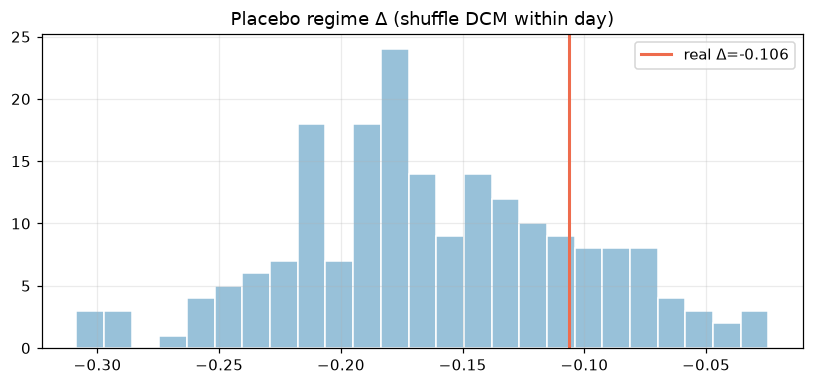

placebo two-sided p≈0.815 (exploratory — not Promote; pass2 placebo_dcm ok=0)
venue panel: 4/9 days with KR spot_l2; 2-venue=5 spot_l2=4 synth=0
trade_synth QUARANTINED; venue-drop ablation deferred — Hold


In [3]:

if p2:
    print(json.dumps({
        "chrono_split": (p2.get("falsifiers") or {}).get("chrono_split"),
        "block_bootstrap_by_day": (p2.get("falsifiers") or {}).get("block_bootstrap_by_day"),
        "placebo_pim_shuffle": (p2.get("falsifiers") or {}).get("placebo_pim_shuffle"),
        "placebo_dcm_regime": (p2.get("falsifiers") or {}).get("placebo_dcm_regime"),
    }, indent=2, default=str)[:3500])

ok = hourly[np.isfinite(hourly["pim"]) & np.isfinite(hourly["notional"])].copy()
# 1) chronological split (preview; canonical numbers in pass2 json)
days = sorted(ok["day"].unique())
mid = max(1, len(days)//2)
early, late = days[:mid], days[mid:]
def corr_sub(sub):
    g = ok[ok["day"].isin(sub)]
    return float(g["notional"].corr(g["pim"])) if len(g)>=5 else float("nan"), len(g)
ce, ne = corr_sub(early); cl, nl = corr_sub(late)
print(f"notebook chrono preview: early {early} corr={ce:.3f} n={ne} | late {late} corr={cl:.3f} n={nl}")

# 2) placebo DCM: shuffle within day then recompute regime delta if possible
rng = np.random.default_rng(42)
placebo_deltas = []
reg = ((el or {}).get("pooled") or {}).get("regime_point") or {}
q_lo, q_hi = reg.get("q_low"), reg.get("q_high")
real_delta = reg.get("delta")
if q_lo is not None and np.isfinite(ok["dcm"]).sum() > 10:
    for _ in range(200):
        shuf = ok.copy()
        shuf["dcm"] = shuf.groupby("day")["dcm"].transform(lambda s: rng.permutation(s.to_numpy()))
        low = shuf[shuf["dcm"] <= q_lo]
        high = shuf[shuf["dcm"] >= q_hi]
        if len(low)>=5 and len(high)>=5:
            dlt = float(high["notional"].corr(high["pim"]) - low["notional"].corr(low["pim"]))
            placebo_deltas.append(dlt)
    placebo_deltas = np.asarray(placebo_deltas)
    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    ax.hist(placebo_deltas, bins=25, color="#98c1d9", edgecolor="white")
    if real_delta is not None:
        ax.axvline(real_delta, color="#ee6c4d", lw=2, label=f"real Δ={real_delta:.3f}")
    ax.set_title("Placebo regime Δ (shuffle DCM within day)"); ax.legend()
    plt.tight_layout(); plt.show()
    if real_delta is not None and placebo_deltas.size:
        p = float(np.mean(np.abs(placebo_deltas) >= abs(real_delta)))
        print(f"placebo two-sided p≈{p:.3f} (exploratory — not Promote; pass2 placebo_dcm ok=0)")
else:
    print("skip placebo — regime quantiles or DCM sparse")

# 3) venue honesty on certified panel
tbl = day_summary_table(pim_panel, inventory=KR_INV)
n3 = int((tbl["n_venues"] >= 3).sum()) if len(tbl) else 0
n_synth = int(tbl["kraken"].isin(["trade_synth", "PROXY_NOT_TOB_trade_synth"]).sum()) if len(tbl) else 0
n_spot = int((tbl["kraken"] == "spot_l2").sum()) if len(tbl) else 0
n_2v = int((tbl["kraken"] == "absent_2venue").sum()) if len(tbl) else 0
print(f"venue panel: {n3}/{len(tbl)} days with KR spot_l2; 2-venue={n_2v} spot_l2={n_spot} synth={n_synth}")
print("trade_synth QUARANTINED; venue-drop ablation deferred — Hold")


## Checklist vs paper §5


In [4]:

checks = [
    ("time-split elasticity", "pass2 chrono_split sign-stable", "Hold"),
    ("block bootstrap CI", "pass2 block_bootstrap_by_day", "Hold"),
    ("placebo PIM shuffle", "pass2 passes", "Hold"),
    ("placebo DCM regime", "inconclusive (ok=0)", "Hold"),
    ("venue drop", "certified 2-venue + spot_l2; synth quarantined — deferred", "Hold"),
    ("BTC widen", "not run", "Hold"),
    ("bank CDS/VaR constituents", "Kill vanity", "Kill"),
    ("TOB-cross α", "Kill", "Kill"),
]
print(f"{'check':32s} {'status':40s} gate")
print("-"*90)
for a,b,g in checks:
    print(f"{a:32s} {b:40s} {g}")


check                            status                                   gate
------------------------------------------------------------------------------------------
time-split elasticity            pass2 chrono_split sign-stable           Hold
block bootstrap CI               pass2 block_bootstrap_by_day             Hold
placebo PIM shuffle              pass2 passes                             Hold
placebo DCM regime               inconclusive (ok=0)                      Hold
venue drop                       certified 2-venue + spot_l2; synth quarantined — deferred Hold
BTC widen                        not run                                  Hold
bank CDS/VaR constituents        Kill vanity                              Kill
TOB-cross α                      Kill                                     Kill


## Signal board


In [5]:

print_board([
    ("risk.cdme_falsifier_board", "Hold", "Pass-2 falsifiers run; 0 Promote"),
    ("risk.bank_cds_var", "Kill", "vanity"),
    ("alpha.tob_cross_arb", "Kill", "never Promote"),
])


id                                 gate   note
----------------------------------------------------------------------------------------
risk.cdme_falsifier_board          Hold   Pass-2 falsifiers run; 0 Promote
risk.bank_cds_var                  Kill   vanity
alpha.tob_cross_arb                Kill   never Promote
